# **تحلیل زمانی**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
file_path = '/content/drive/My Drive/Zahra/Year_403.xlsx'
df = pd.read_excel(file_path)

Mounted at /content/drive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601217 entries, 0 to 601216
Data columns (total 43 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Value added insurance premium     601217 non-null  int64  
 1   Received from the driver          601217 non-null  int64  
 2   Scale fee                         601217 non-null  int64  
 3   Evacuation fee                    601217 non-null  int64  
 4   added value                       601217 non-null  int64  
 5   Complications of moving goods     601217 non-null  int64  
 6   Bill of lading registration time  601217 non-null  object 
 7   Tracking code watch               601217 non-null  object 
 8   date of interception              601217 non-null  object 
 9   Company commission                601217 non-null  int64  
 10  Insurance amount                  601217 non-null  int64  
 11  Loading fee                       601217 non-null  i

In [ ]:
df['Date of issue'].head()

,Date of issue
0,1403/01/05
1,1403/01/05
2,1403/01/05
3,1403/01/05
4,1403/01/05


In [ ]:
df['Delivery date'].head()

,Delivery date
0,1403/01/06
1,1403/01/06
2,1403/01/06
3,1403/01/06
4,1403/01/06


In [ ]:
!pip install jdatetime

In [ ]:
import pandas as pd
import jdatetime

print(" قبل از تبدیل:")
print(df['Date of issue'])
print(df['Date of issue'].dtype)  # نوع ستون قبل از تبدیل

def shamsi_to_gregorian(date_str):
    try:
        y, m, d = map(int, date_str.split('/'))
        return jdatetime.date(y, m, d).togregorian()
    except:
        return None  # اگه تاریخ خراب بود یا NaN بود

df['Date of issue'] = df['Date of issue'].apply(shamsi_to_gregorian)

df['Date of issue'] = pd.to_datetime(df['Date of issue'])

print("\n بعد از تبدیل:")
print(df['Date of issue'])
print(df['Date of issue'].dtype)

 قبل از تبدیل:
0         1403/01/05
1         1403/01/05
2         1403/01/05
3         1403/01/05
4         1403/01/05
             ...    
601212    1403/12/27
601213    1403/12/27
601214    1403/12/28
601215    1403/12/28
601216    1403/12/27
Name: Date of issue, Length: 601217, dtype: object
object

 بعد از تبدیل:
0        2024-03-24
1        2024-03-24
2        2024-03-24
3        2024-03-24
4        2024-03-24
            ...    
601212   2025-03-17
601213   2025-03-17
601214   2025-03-18
601215   2025-03-18
601216   2025-03-17
Name: Date of issue, Length: 601217, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
df['year'] = df['Date of issue'].dt.year
df['month'] = df['Date of issue'].dt.month
df['day'] = df['Date of issue'].dt.day
df['weekday'] = df['Date of issue'].dt.day_name()

In [ ]:
df['year'].head()

,year
0,2024
1,2024
2,2024
3,2024
4,2024


In [ ]:
#گروه بندی بر اساس ماه
monthly_count = df.groupby(df['Date of issue'].dt.to_period('M')).size()
print(monthly_count)

Date of issue
2023-04        4
2023-06        5
2023-07        3
2023-10        8
2023-12        1
2024-02        1
2024-03     6614
2024-04    45111
2024-05    49875
2024-06    43872
2024-07    45271
2024-08    47917
2024-09    47492
2024-10    57966
2024-11    54568
2024-12    56489
2025-01    53832
2025-02    51425
2025-03    40763
Freq: M, dtype: int64


تعداد ردیف های که در هر ماه هست را شمرده و نمایش داده

# مدل سازی زمان رسیدن

In [ ]:
# محاسبه مدت زمان رسیدن به روز (یا ساعت)
df['delivery_duration'] = (df['Delivery date'] - df['Date of issue']).dt.total_seconds() / 3600  # به ساعت

In [ ]:
df = df[df['delivery_duration'] >= 0]
df = df[df['delivery_duration'] < 1000]  # مثلا فیلتر روی بازه منطقی

In [ ]:
df['issue_weekday'] = df['Date of issue'].dt.weekday
df['issue_hour'] = df['Date of issue'].dt.hour

In [ ]:
# حذف رکوردهایی که هر کدوم از ویژگی‌های کلیدی ناقص هستن
df = df.dropna(subset=['delivery_duration', 'weight', 'distance'])

# حذف مقادیر خیلی پرت، مثلا اگر delivery_duration خیلی بزرگه
max_duration = df['delivery_duration'].quantile(0.99)  # 99 درصد داده‌ها پایین‌تر از این مقدار هستن
df = df[df['delivery_duration'] <= max_duration]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# هدف
y = df['delivery_duration']

# ویژگی‌ها (مثال)
numerical_features = ['weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value',
                      'Insurance amount', 'Loading fee', 'rent']

categorical_features = ['product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name']

X = df[numerical_features + categorical_features]

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators = 20, max_depth = 15, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f} hours')
print(f'R^2: {r2:.4f}')

RMSE: 7.82 hours
R^2: -0.0354


In [ ]:
numerical_features = ['weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value',
                      'Insurance amount', 'Loading fee', 'rent', 'issue_weekday', 'issue_hour']

categorical_features = ['product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df[numerical_features + categorical_features]
y = df['delivery_duration']

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=20, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f} hours')
print(f'R^2: {r2:.4f}')

RMSE: 1.81 hours
R^2: 0.4675


میانگین خطای پیش‌بینی مدل حدود 1.8 ساعت هست. یعنی در تخمین زمان رسیدن، به طور متوسط مدل حدود 1 ساعت و 48 دقیقه اختلاف با زمان واقعی داره

In [ ]:
import xgboost as xgb

model_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(n_estimators=100, max_depth=6, random_state=42, verbosity=0))
])

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'XGBoost RMSE: {rmse_xgb:.2f} hours')
print(f'XGBoost R^2: {r2_xgb:.4f}')

XGBoost RMSE: 1.82 hours
XGBoost R^2: 0.4610


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

param_dist = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [3, 6, 10, 15],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.6, 0.8, 1.0]
}

model_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(random_state=42))
])

search = RandomizedSearchCV(model_xgb, param_distributions=param_dist, n_iter=10, cv=3, scoring='r2', verbose=2, random_state=42)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R2:", search.best_score_)

best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Optimized XGBoost RMSE: {rmse:.2f} hours')
print(f'Optimized XGBoost R^2: {r2:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END regressor__learning_rate=0.2, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=1.0; total time=   4.3s
[CV] END regressor__learning_rate=0.2, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=1.0; total time=   2.9s
[CV] END regressor__learning_rate=0.2, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=1.0; total time=   2.9s
[CV] END regressor__learning_rate=0.01, regressor__max_depth=6, regressor__n_estimators=50, regressor__subsample=0.8; total time=   3.0s
[CV] END regressor__learning_rate=0.01, regressor__max_depth=6, regressor__n_estimators=50, regressor__subsample=0.8; total time=   5.2s
[CV] END regressor__learning_rate=0.01, regressor__max_depth=6, regressor__n_estimators=50, regressor__subsample=0.8; total time=   2.8s
[CV] END regressor__learning_rate=0.01, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.8

Exception ignored in: <function DataIter.__del__ at 0x7b1a47cc1800>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/xgboost/core.py", line 575, in __del__
    assert self._temporary_data is None
           ^^^^^^^^^^^^^^^^^^^^
AttributeError: 'SingleBatchInternalIter' object has no attribute '_temporary_data'


[CV] END regressor__learning_rate=0.1, regressor__max_depth=10, regressor__n_estimators=200, regressor__subsample=1.0; total time=  15.2s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=10, regressor__n_estimators=200, regressor__subsample=1.0; total time=  17.6s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=15, regressor__n_estimators=100, regressor__subsample=0.8; total time=  18.4s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=15, regressor__n_estimators=100, regressor__subsample=0.8; total time=  17.3s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=15, regressor__n_estimators=100, regressor__subsample=0.8; total time=  17.6s
[CV] END regressor__learning_rate=0.01, regressor__max_depth=15, regressor__n_estimators=100, regressor__subsample=0.6; total time=  23.1s
[CV] END regressor__learning_rate=0.01, regressor__max_depth=15, regressor__n_estimators=100, regressor__subsample=0.6; total time=  24.6s
[CV] END regressor__learning_rat

## ساخت ویژگی های ترکیبی  زمانی

In [ ]:
import numpy as np
import pandas as pd

# 1. نسبت وزن به مسافت
df['weight_distance_ratio'] = df['weight'] / (df['distance'] + 1)  # +1 برای جلوگیری از تقسیم بر صفر

# 2. جمع هزینه‌ها (مثال: Scale fee + Evacuation fee + Loading fee)
df['total_fee'] = df['Scale fee'] + df['Evacuation fee'] + df['Loading fee']

# 4. تعداد روز از تاریخ صدور تا تاریخ رسیدن
df['Delivery date'] = pd.to_datetime(df['Delivery date'], errors='coerce')
df['days_since_issue'] = (df['Delivery date'] - df['Date of issue']).dt.days

# 5. آیا تاریخ صدور در روز تعطیل (شنبه=5، یکشنبه=6)
df['is_weekend'] = df['Date of issue'].dt.weekday.isin([5,6]).astype(int)

# 6. ترکیب محصول و شهر مبدا به صورت رشته
df['product_city_interaction'] = df['product name'] + '_' + df['Name of the city of orgin']

# 7. هزینه کل تقسیم بر مسافت (میانگین هزینه به ازای هر کیلومتر)
df['avg_fee_per_km'] = df['total_fee'] / (df['distance'] + 1)


In [ ]:
numerical_features = [
    'weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value',
    'Insurance amount', 'Loading fee', 'rent',
    'weight_distance_ratio', 'total_fee', 'days_since_issue', 'avg_fee_per_km'
]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y = df['delivery_duration']

X = df[numerical_features + categorical_features]

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f} hours')
print(f'R^2: {r2:.4f}')

RMSE: 0.00 hours
R^2: 1.0000


In [ ]:
# انتخاب فقط ستون‌های عددی
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# محاسبه همبستگی عددی‌ها با هدف delivery_duration
correlations = numeric_df.corr()['delivery_duration'].abs().sort_values(ascending=False)

print("همبستگی ویژگی‌های عددی با هدف:\n", correlations)

همبستگی ویژگی‌های عددی با هدف:
 days_since_issue                 1.000000
delivery_duration                1.000000
Company commission               0.078074
Loading fee                      0.056060
total_fee                        0.053897
Sender is national ID            0.049714
Postal code of recipient         0.047435
Recipient is national ID         0.043118
weight                           0.036758
product code                     0.033956
Scale fee                        0.032776
Total fare                       0.032457
Destination city code            0.030603
Serial code                      0.030572
Postal code of the sender        0.027984
Bill of lading number            0.025961
Loader code                      0.025871
avg_fee_per_km                   0.023687
Complications of moving goods    0.022768
rent                             0.022759
Calculation fare                 0.022655
Driver smart card                0.020347
distance                         0.018993
is

In [ ]:
high_corr_features = correlations[(correlations > 0.9) & (correlations.index != 'delivery_duration')].index.tolist()

print("ویژگی‌هایی که حذف می‌شوند به خاطر همبستگی زیاد:", high_corr_features)

df = df.drop(columns=high_corr_features)

ویژگی‌هایی که حذف می‌شوند به خاطر همبستگی زیاد: ['days_since_issue']


In [ ]:
numerical_features = [col for col in ['weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value',
                                     'Insurance amount', 'Loading fee', 'rent']
                      if col in df.columns]

categorical_features = [col for col in ['product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name']
                        if col in df.columns]

y = df['delivery_duration']
X = df[numerical_features + categorical_features]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f} hours')
print(f'R^2: {r2:.4f}')

RMSE: 1.85 hours
R^2: 0.4432


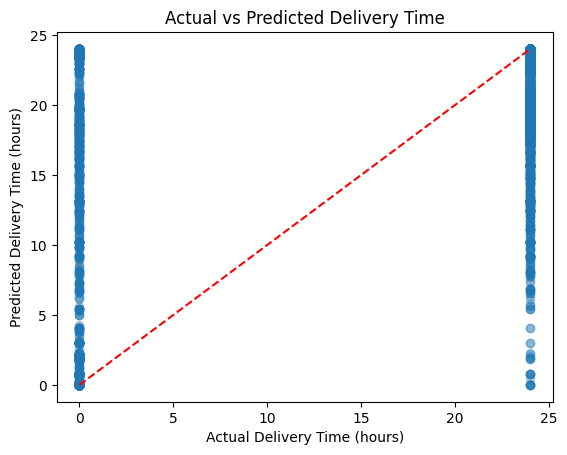

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Delivery Time (hours)')
plt.ylabel('Predicted Delivery Time (hours)')
plt.title('Actual vs Predicted Delivery Time')
plt.show()

## آموزش مدل پس از نرمال سازی داده ها

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y = df['delivery_duration']

numerical_features = ['weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value',
                      'Insurance amount', 'Loading fee', 'rent']

categorical_features = ['product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name']

X = df[numerical_features + categorical_features]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f} hours')
print(f'R^2: {r2:.4f}')

RMSE: 1.85 hours
R^2: 0.4430


نتیجه می شود برای تخمین زمان رسیدن  بالاترین دقت همان 47 درصد است

شاید با بررسی ویزگی های بیشتر و استفاده از روش های پیشرفته مهندسی ویژگی ها  بتوان دقت مدل را نهایتا به

پنجاه درصد رساند

## بررسی و نمونه گیری

In [ ]:
# ابتدا مطمئن شویم X_test حاوی ستون‌های مورد نیاز است
print("ستون‌های X_test:", X_test.columns.tolist())

# اگر ستون‌های issue_hour و issue_weekday وجود ندارند، باید آنها را ایجاد کنیم
# معمولاً این ستون‌ها از ستون تاریخ استخراج می‌شوند

# نمونه کد برای ایجاد این ستون‌ها (اگر در داده اصلی ستون تاریخ دارید):
# فرض می‌کنیم ستون اصلی 'issue_date' نام دارد
# X_test['issue_hour'] = X_test['issue_date'].dt.hour
# X_test['issue_weekday'] = X_test['issue_date'].dt.weekday

# راه حل جایگزین: استفاده از iloc به جای loc
np.random.seed(42)
random_indices = np.random.choice(range(len(X_test)), size=5, replace=False)
sample_X = X_test.iloc[random_indices]
sample_y = y_test.iloc[random_indices]

print("ستون‌های نمونه:", sample_X.columns.tolist())

# اگر همچنان مشکل وجود داشت، بررسی کنیم آیا پیش‌پردازش به درستی انجام شده
# ممکن است نیاز باشد این ستون‌ها را در داده اصلی ایجاد کنید

ستون‌های X_test: ['weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value', 'Insurance amount', 'Loading fee', 'rent', 'product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name']
ستون‌های نمونه: ['weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value', 'Insurance amount', 'Loading fee', 'rent', 'product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name']


In [ ]:
# ایجاد ستون‌های جدید روی داده اصلی قبل از split
df['issue_weekday'] = pd.to_datetime(df['Date of issue']).dt.weekday
df['issue_hour'] = pd.to_datetime(df['Date of issue']).dt.hour

X = df.drop('delivery_duration', axis=1)
y = df['delivery_duration']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# بررسی ستون‌های X_train و X_test
print("ستون‌های X_train:", X_train.columns.tolist())
print("ستون‌های X_test:", X_test.columns.tolist())

# اگر ستون‌های مورد نظر وجود ندارند:
X_train['issue_weekday'] = pd.to_datetime(X_train['Date of issue']).dt.weekday
X_train['issue_hour'] = pd.to_datetime(X_train['Date of issue']).dt.hour

X_test['issue_weekday'] = pd.to_datetime(X_test['Date of issue']).dt.weekday
X_test['issue_hour'] = pd.to_datetime(X_test['Date of issue']).dt.hour

ستون‌های X_train: ['Value added insurance premium', 'Received from the driver', 'Scale fee', 'Evacuation fee', 'added value', 'Complications of moving goods', 'Bill of lading registration time', 'Tracking code watch', 'date of interception', 'Company commission', 'Insurance amount', 'Loading fee', 'Total fare', 'Recipient is national ID', 'Sender is national ID', 'Postal code of recipient', 'Postal code of the sender', 'interception', 'Device smart card', 'Driver smart card', 'Packaging code', 'License plate code', 'Serial code', 'License plate number', 'Unnamed: 24', 'Delivery date', 'Date of issue', 'Loader code', 'The name of the destination city', 'Destination city code', 'Name of the city of orgin', 'Code of the city of orgin', 'product name', 'product code', 'distance', 'weight', 'Calculation fare', 'rent', 'Bill of lading number', 'Bill of lading series', 'Company name', 'Company Code', 'year', 'month', 'day', 'weekday', 'issue_weekday', 'issue_hour', 'weight_distance_ratio', 't

In [ ]:
from sklearn.preprocessing import FunctionTransformer

def extract_datetime_features(df):
    df = df.copy()
    df['issue_weekday'] = pd.to_datetime(df['Date of issue']).dt.weekday
    df['issue_hour'] = pd.to_datetime(df['Date of issue']).dt.hour
    return df.drop('Date of issue', axis=1)  # حذف ستون اصلی تاریخ

# اضافه کردن به Pipeline
model_xgb = Pipeline([
    ('feature_extractor', FunctionTransformer(extract_datetime_features)),
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(random_state=42))
])

In [ ]:
# اطمینان از وجود ستون‌ها در داده تست
print("ستون‌های X_test:", X_test.columns.tolist())

# نمونه‌گیری مجدد
np.random.seed(42)
sample_X = X_test.sample(5)
sample_y = y_test.loc[sample_X.index]

# پیش‌بینی
sample_pred = best_model.predict(sample_X)

# نمایش نتایج
results = pd.DataFrame({
    'مقدار واقعی': sample_y,
    'پیش‌بینی مدل': sample_pred,
    'اختلاف (ساعت)': np.abs(sample_y - sample_pred)
})

print("\nنتایج پیش‌بینی روی نمونه‌های تصادفی:")
print(results)
print("\nمیانگین اختلاف:", results['اختلاف (ساعت)'].mean().round(2), "ساعت")

ستون‌های X_test: ['Value added insurance premium', 'Received from the driver', 'Scale fee', 'Evacuation fee', 'added value', 'Complications of moving goods', 'Bill of lading registration time', 'Tracking code watch', 'date of interception', 'Company commission', 'Insurance amount', 'Loading fee', 'Total fare', 'Recipient is national ID', 'Sender is national ID', 'Postal code of recipient', 'Postal code of the sender', 'interception', 'Device smart card', 'Driver smart card', 'Packaging code', 'License plate code', 'Serial code', 'License plate number', 'Unnamed: 24', 'Delivery date', 'Date of issue', 'Loader code', 'The name of the destination city', 'Destination city code', 'Name of the city of orgin', 'Code of the city of orgin', 'product name', 'product code', 'distance', 'weight', 'Calculation fare', 'rent', 'Bill of lading number', 'Bill of lading series', 'Company name', 'Company Code', 'year', 'month', 'day', 'weekday', 'issue_weekday', 'issue_hour', 'weight_distance_ratio', 'to

In [ ]:
import pandas as pd
import numpy as np

# ایجاد DataFrame برای نتایج
results = pd.DataFrame({
    'مقدار واقعی': sample_y,
    'پیش‌بینی مدل': sample_pred,
    'اختلاف (ساعت)': np.abs(sample_y - sample_pred)
}, index=random_indices)

# تنظیمات نمایش برای زیباسازی
results_styled = results.style \
    .set_caption('نتایج پیش‌بینی مدل روی نمونه‌های تصادفی') \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '16px'), ('font-weight', 'bold')]
    }]) \
    .format({
        'پیش‌بینی مدل': '{:.3f}',
        'اختلاف (ساعت)': '{:.3f}'
    }) \
    .highlight_min(subset=['اختلاف (ساعت)'], color='green') \
    .highlight_max(subset=['اختلاف (ساعت)'], color='red')

results_styled

,مقدار واقعی,پیش‌بینی مدل,اختلاف (ساعت)
161454,24.000000,23.991,0.009
99691,24.000000,23.972,0.028
314288,24.000000,23.996,0.004
182013,24.000000,23.972,0.028
527039,24.000000,23.994,0.006


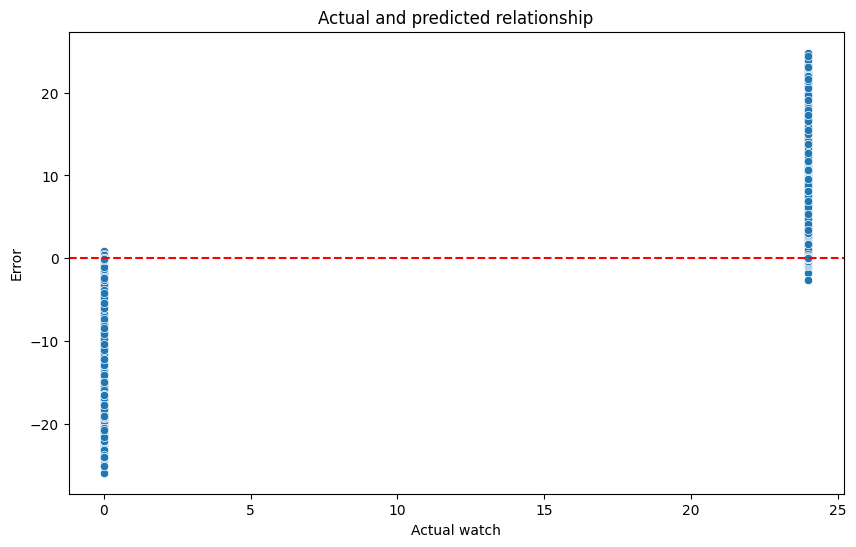

میانگین خطای مطلق (MAE): 0.2533 ساعت
میانه خطای مطلق (MedAE): 0.0109 ساعت


In [ ]:
import seaborn as sns
# تحلیل خطا روی کل مجموعه تست
test_predictions = best_model.predict(X_test)
errors = y_test - test_predictions

# 2. رابطه خطا با مقدار واقعی
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=errors)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Actual and predicted relationship')
plt.xlabel('Actual watch')
plt.ylabel('Error')
plt.show()

# 3. محاسبه معیارهای دقیق‌تر
from sklearn.metrics import mean_absolute_error, median_absolute_error

mae = mean_absolute_error(y_test, test_predictions)
medae = median_absolute_error(y_test, test_predictions)

print(f'میانگین خطای مطلق (MAE): {mae:.4f} ساعت')
print(f'میانه خطای مطلق (MedAE): {medae:.4f} ساعت')

In [ ]:
# روش وزندهی نمونه‌ها در XGBoost
model = xgb.XGBRegressor(
    scale_pos_weight=sum(y != 24) / sum(y == 24),  # نسبت نمونه‌های غیر 24 ساعتی به 24 ساعتی
)

In [ ]:
# ایجاد ویژگی‌های تعاملی
df['is_24h'] = (df['delivery_duration'] == 24).astype(int)

# ایجاد بسته‌های زمانی
bins = [0, 12, 24, 48, 1000]
labels = ['کوتاه', 'متوسط', 'طولانی', 'خیلی طولانی']
df['duration_category'] = pd.cut(df['delivery_duration'], bins=bins, labels=labels)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# کاهش نمونه‌های 24 ساعتی
rus = RandomUnderSampler(sampling_strategy={24: sum(y == 24)//2}, random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error

# تعریف مجدد مدل و پارامترها
model_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(random_state=42))
])

param_dist = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [3, 6, 10, 15],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.6, 0.8, 1.0]
}

# ایجاد RandomizedSearchCV با معیار MAE
search = RandomizedSearchCV(
    estimator=model_xgb,  # اضافه کردن estimator
    param_distributions=param_dist,  # اضافه کردن param_distributions
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',  # معیار جدید
    verbose=2,
    random_state=42,
    n_jobs=-1  # استفاده از تمام هسته‌های پردازنده
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)  # تبدیل به مقدار مثبت

best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Optimized XGBoost MAE: {mae:.2f} hours')
print(f'Optimized XGBoost R^2: {r2:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'regressor__subsample': 0.8, 'regressor__n_estimators': 100, 'regressor__max_depth': 15, 'regressor__learning_rate': 0.1}
Best CV MAE: 0.26386246412371933
Optimized XGBoost MAE: 0.27 hours
Optimized XGBoost R^2: 0.4510


In [ ]:
# ایجاد یک ویژگی جدید برای تشخیص 24 ساعت
X_train['is_24h'] = (y_train == 24).astype(int)
X_test['is_24h'] = (y_test == 24).astype(int)

# اضافه کردن این ویژگی به pipeline
# (باید در preprocessor گنجانده شود)

# سپس آموزش مجدد مدل
search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['weight',
                                                                                'distance',
                                                                                'Scale '
                                                                                'fee',
                                                                                'Evacuation '
                                                                                'fee',
                                                                                'added '
                                                                                'value',
                                                                                'Insurance '
                                                                                'amount',
                                                                                'Loading '
                                                                                'fee',
                                                                                'rent']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['product '
                                                                                'name',
                                                                                'The '
                                                                                'name '
                                                                                'of '
                                                                                'the '
                                                                                'destination '
                                                                                'city',
                                                                                'Name '
                                                                                'of '
                                                                                'the...
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'regressor__learning_rate': [0.01, 0.1,
                                                                     0.2],
                                        'regressor__max_depth': [3, 6, 10, 15],
                                        'regressor__n_estimators': [50, 100,
                                                                    200],
                                        'regressor__subsample': [0.6, 0.8,
                                                                 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=2)

In [ ]:
print(f'Optimized XGBoost R^2: {r2:.4f}')

Optimized XGBoost R^2: 0.4510


#   بررسی روند زمانی صدور کالا

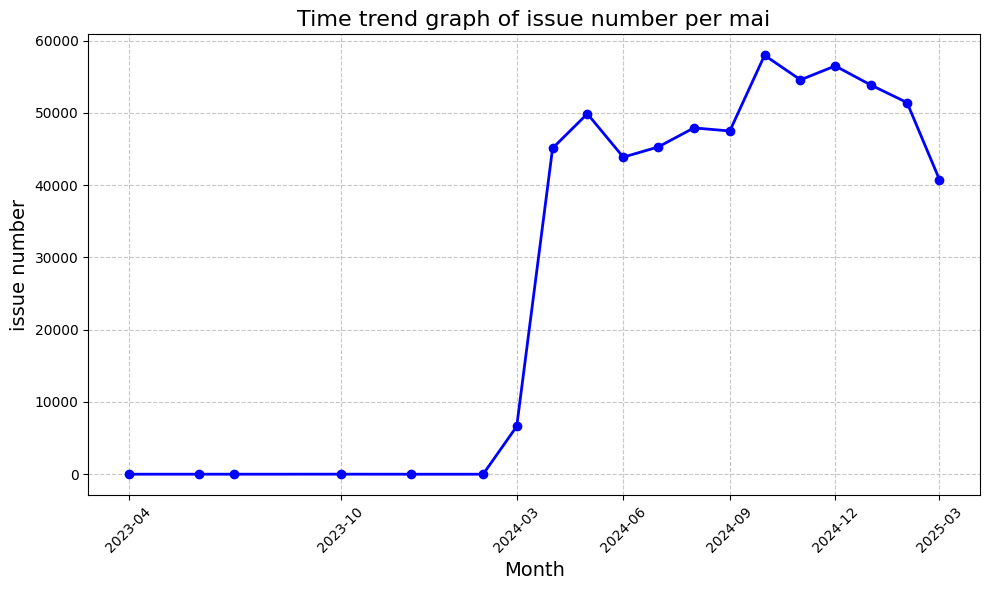

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# گروه بندی بر اساس ماه
monthly_count = df.groupby(df['Date of issue'].dt.to_period('M')).size()
monthly_count.index = monthly_count.index.to_timestamp()  # تبدیل به datetime برای محور X

# رسم نمودار
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly_count.index, monthly_count.values, marker='o', color='blue', linewidth=2)

# عنوان و لیبل‌ها
ax.set_title("Time trend graph of issue number per mai", fontsize=16)
ax.set_xlabel("Month", fontsize=14)
ax.set_ylabel("issue number", fontsize=14)

# تنظیم محور Y: بازه‌های واضح (مثلاً هر 10هزار تا)
y_max = monthly_count.max()
ax.set_yticks(range(0, int(y_max)+10000, 10000))

# تنظیم محور X: نمایش تاریخ‌های دقیق، ولی هر ۳ ماه یک لیبل برای شلوغ نشدن
ax.set_xticks(monthly_count.index[::3])
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_count.index[::3]], rotation=45)

# شبکه کم‌رنگ برای وضوح بهتر
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

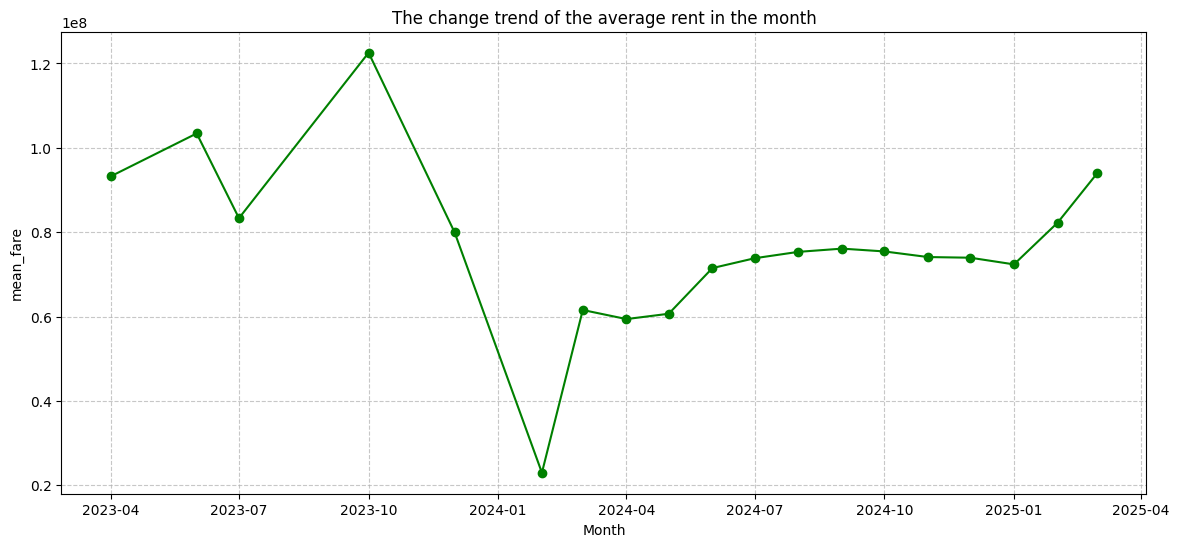

In [ ]:
# میانگین کرایه  به تفکیک ماه
fare_monthly = df.groupby(df['Date of issue'].dt.to_period('M'))['Calculation fare'].mean()

# تبدیل به datetime برای رسم
fare_monthly.index = fare_monthly.index.to_timestamp()

# رسم روند تغییرات کرایه
plt.figure(figsize=(14,6))
plt.plot(fare_monthly.index, fare_monthly.values, marker='o', color='green')
plt.title("The change trend of the average rent in the month")
plt.xlabel("Month")
plt.ylabel("mean_fare")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

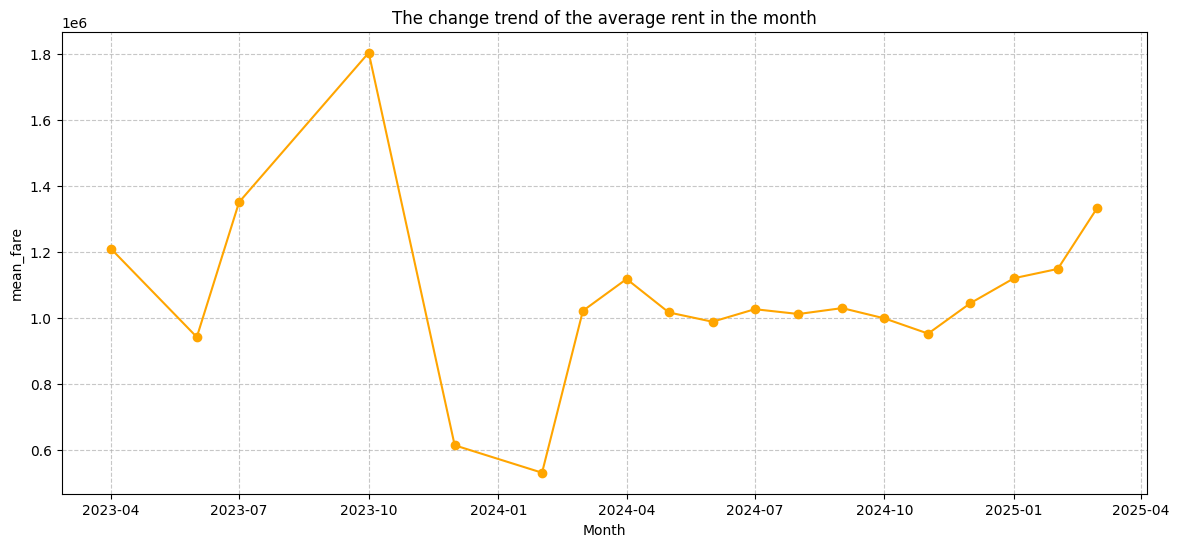

In [ ]:
#میانگین بیمه به تفکیک ماه
fare_monthly = df.groupby(df['Date of issue'].dt.to_period('M'))['Insurance amount'].mean()

# تبدیل به datetime برای رسم
fare_monthly.index = fare_monthly.index.to_timestamp()

# رسم روند تغییرات کرایه
plt.figure(figsize=(14,6))
plt.plot(fare_monthly.index, fare_monthly.values, marker='o', color='orange')
plt.title("The change trend of the average rent in the month")
plt.xlabel("Month")
plt.ylabel("mean_fare")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# محاسبه تعداد بارگیری برای هر کد بارگیر
df['LoadingCount'] = df.groupby('Loader code')['Loader code'].transform('count')

In [ ]:
# گروه‌بندی بر اساس کد بارگیر و شمارش تعداد بارگیری
loader_counts = df.groupby('Loader code').size().reset_index(name='LoadingCount')
loader_counts

,Loader code,LoadingCount
0,101,43
1,103,1916
2,104,19676
3,114,947
4,115,334
...,...,...
130,632,1538
131,634,234
132,705,2
133,706,1360


In [ ]:
loader_stats = df.groupby('Loader code').agg(
    LoadingCount=('Loader code', 'count'),
    TotalLoadingFee=('Loading fee', 'sum')
).reset_index()

print(loader_stats)

     Loader code  LoadingCount  TotalLoadingFee
0            101            43                0
1            103          1916       1128822004
2            104         19676       8469066520
3            114           947        248092961
4            115           334         80914001
..           ...           ...              ...
130          632          1538        784244032
131          634           234        133619030
132          705             2                0
133          706          1360        230441350
134          707           227         25800000

[135 rows x 3 columns]


چرا در بعضی رکورد ها هزینه بارگیری صفر شده؟ آیا واقعا هزینه بارگیری صفر می شود؟

In [ ]:
# بررسی رکوردهایی که هزینه بارگیری صفر دارن
df[df['Loading fee'] == 0][['Loader code', 'Loading fee', 'Date of issue']]

,Loader code,Loading fee,Date of issue
0,505,0,2024-03-24
1,505,0,2024-03-24
2,505,0,2024-03-24
3,505,0,2024-03-24
5,500,0,2024-03-23
...,...,...,...
601212,358,0,2025-03-17
601213,131,0,2025-03-17
601214,355,0,2025-03-18
601215,118,0,2025-03-18


In [ ]:
print("تعداد هزینه بارگیری صفر:", (df['Loading fee'] == 0).sum())
print("تعداد مقادیر خالی (NaN):", df['Loading fee'].isna().sum())

تعداد هزینه بارگیری صفر: 539581
تعداد مقادیر خالی (NaN): 0


In [ ]:
print(df['Loading fee'].dtype)

int64


In [ ]:
print(df['Loading fee'].head(20))

0           0
1           0
2           0
3           0
4     1500000
5           0
6           0
7           0
8           0
9           0
10          0
11          0
12          0
13          0
14          0
15          0
16          0
17          0
18          0
19          0
Name: Loading fee, dtype: int64


In [ ]:
# فیلتر رکوردهای هزینه بارگیری صفر
zero_fee_records = df[df['Loading fee'] == 0]

print("تعداد رکوردهای هزینه بارگیری صفر:", len(zero_fee_records))
zero_fee_records.head(10)

تعداد رکوردهای هزینه بارگیری صفر: 539581


,Value added insurance premium,Received from the driver,Scale fee,Evacuation fee,added value,Complications of moving goods,Bill of lading registration time,Tracking code watch,date of interception,Company commission,...,rent,Bill of lading number,Bill of lading series,Company name,Company Code,year,month,day,weekday,LoadingCount
0,144000,12669000,0,0,0,5616000,14:04,14:05,1403/01/05,5,...,62400000,3542008,1402/14,بلم لجستيک,111100195,2024,3,24,Sunday,85912
1,144000,12669000,0,0,0,5616000,13:21,13:22,1403/01/05,4992000,...,62400000,3542007,1402/14,بلم لجستيک,111100195,2024,3,24,Sunday,85912
2,144000,12704000,0,0,0,5634000,13:12,13:13,1403/01/05,5008000,...,62600000,3542005,1402/14,بلم لجستيک,111100195,2024,3,24,Sunday,85912
3,144000,12704000,0,0,0,5634000,13:16,13:17,1403/01/05,5008000,...,62600000,3542006,1402/14,بلم لجستيک,111100195,2024,3,24,Sunday,85912
5,7020,1700000,0,0,0,1800000,14:10,14:11,1403/01/04,1600000,...,20000000,4149269,1402/14,سمند ترابر بين الملل,111100923,2024,3,23,Saturday,1699
6,7020,1700000,0,0,0,1800000,12:54,12:55,1403/01/05,1600000,...,20000000,4149308,1402/14,سمند ترابر بين الملل,111100923,2024,3,24,Sunday,36156
7,7020,1275000,0,0,0,1350000,13:01,13:01,1403/01/05,1200000,...,15000000,4149312,1402/14,سمند ترابر بين الملل,111100923,2024,3,24,Sunday,12155
8,7020,1700000,0,0,0,1800000,13:00,13:00,1403/01/05,1600000,...,20000000,4149311,1402/14,سمند ترابر بين الملل,111100923,2024,3,24,Sunday,1856
9,7020,1700000,0,0,0,1800000,13:02,13:03,1403/01/05,1600000,...,20000000,4149313,1402/14,سمند ترابر بين الملل,111100923,2024,3,24,Sunday,36156
10,7020,1700000,0,0,0,1800000,14:22,14:22,1403/01/05,1600000,...,20000000,4149327,1402/14,سمند ترابر بين الملل,111100923,2024,3,24,Sunday,15671


ماه‌هایی با بیشترین هزینه صفر:
  Date of issue  ZeroFeeCount
0    2023-04-01             1
1    2023-06-01             4
2    2023-07-01             2
3    2023-10-01             3
4    2023-12-01             1
5    2024-02-01             1
6    2024-03-01          4262
7    2024-04-01         33059
8    2024-05-01         44371
9    2024-06-01         39136


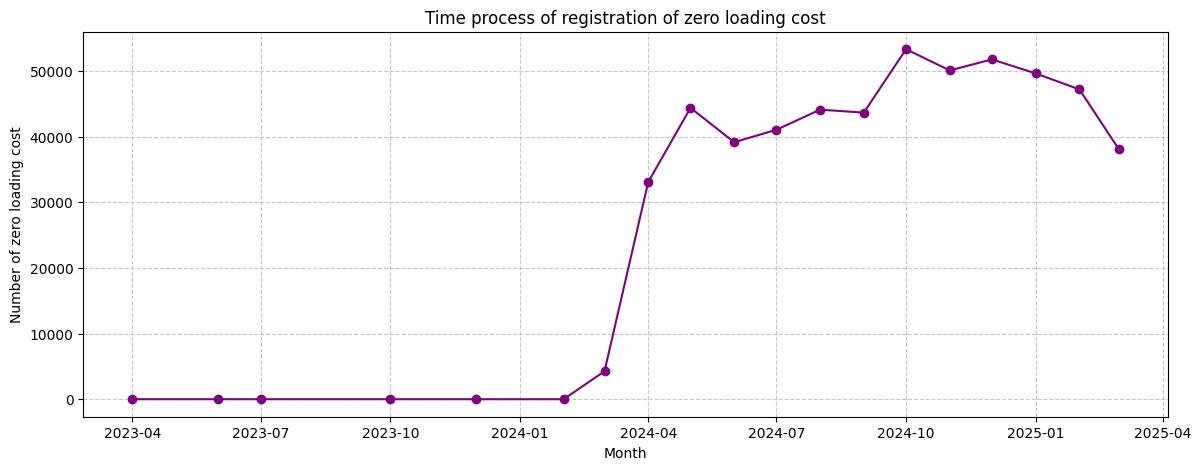

In [ ]:
# بررسی در چه ماه‌هایی هزینه صفر ثبت شده
zero_by_month = zero_fee_records.groupby(zero_fee_records['Date of issue'].dt.to_period('M')).size().reset_index(name='ZeroFeeCount')
zero_by_month['Date of issue'] = zero_by_month['Date of issue'].dt.to_timestamp()

print("ماه‌هایی با بیشترین هزینه صفر:")
print(zero_by_month.head(10))


plt.figure(figsize=(14,5))
plt.plot(zero_by_month['Date of issue'], zero_by_month['ZeroFeeCount'], marker='o', color='purple')
plt.title("Time process of registration of zero loading cost")
plt.xlabel("Month")
plt.ylabel("Number of zero loading cost")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# گروه بندی بر اساس ماه و شمارش تعداد بارگیری
loading_by_month = df.groupby(df['Date of issue'].dt.to_period('M'))['Loader code'].count().reset_index(name='LoadingCount')

# تبدیل به تاریخ برای رسم
loading_by_month['Date of issue'] = loading_by_month['Date of issue'].dt.to_timestamp()

# مرتب‌سازی بر اساس تعداد بارگیری
loading_by_month_sorted = loading_by_month.sort_values(by='LoadingCount', ascending=False)

print("ماه‌هایی با بیشترین تعداد بارگیری:")
print(loading_by_month_sorted.head(10))

ماه‌هایی با بیشترین تعداد بارگیری:
   Date of issue  LoadingCount
13    2024-10-01         57966
15    2024-12-01         56489
14    2024-11-01         54568
16    2025-01-01         53832
17    2025-02-01         51425
8     2024-05-01         49875
11    2024-08-01         47917
12    2024-09-01         47492
10    2024-07-01         45271
7     2024-04-01         45111


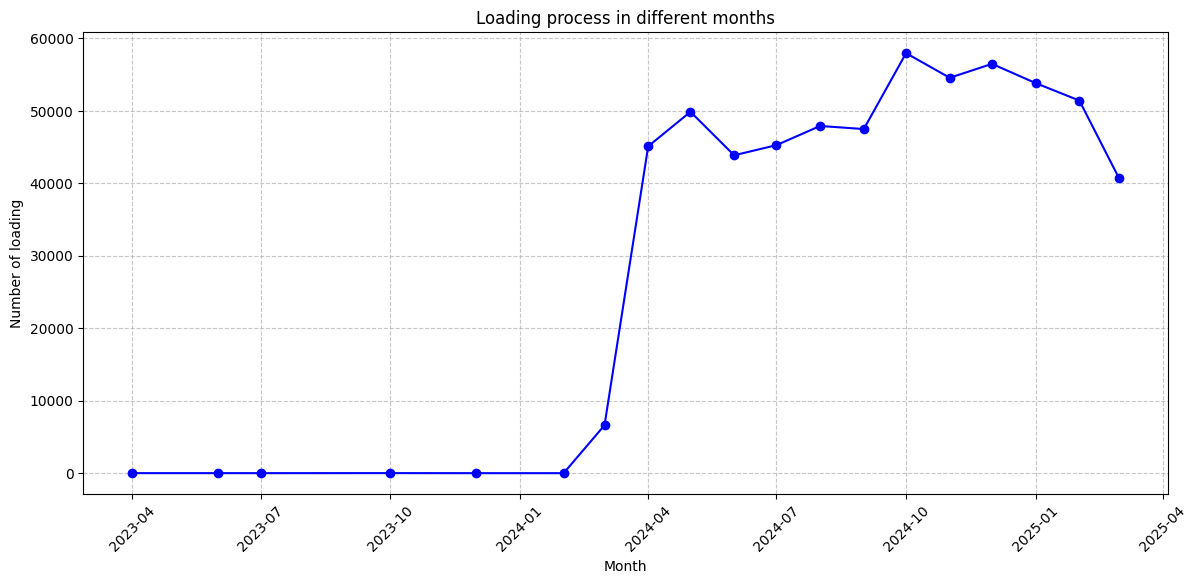

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(loading_by_month['Date of issue'], loading_by_month['LoadingCount'], marker='o', color='blue')
plt.title("Loading process in different months")
plt.xlabel("Month")
plt.ylabel("Number of loading")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# گروه‌بندی بر اساس ماه و شمارش تعداد بارگیری‌ها
loading_by_month = df.groupby(df['Date of issue'].dt.to_period('M')).size().reset_index(name='LoadingCount')

# تبدیل ستون تاریخ به نوع Timestamp برای راحتی نمایش
loading_by_month['Date of issue'] = loading_by_month['Date of issue'].dt.to_timestamp()

# پیدا کردن ماه با بیشترین تعداد بارگیری
max_loading_month = loading_by_month.loc[loading_by_month['LoadingCount'].idxmax()]

print(f"بیشترین بارگیری در ماه {max_loading_month['Date of issue'].strftime('%Y-%m')} با تعداد {max_loading_month['LoadingCount']} بارگیری انجام شده است")

بیشترین بارگیری در ماه 2024-10 با تعداد 57966 بارگیری انجام شده است


پس حدود مهر اوایل آبان 1403 ما بیشترین بارگیری یا همون صدور محصول را داشته ایم

In [ ]:
df['Loading fee'].head()

,Loading fee
0,0
1,0
2,0
3,0
4,1500000


In [ ]:
print("تعداد کل رکوردها:", len(df))
print("تعداد رکوردهای هزینه صفر:", (df['Loading fee'] == 0).sum())
print("تعداد رکوردهای غیر صفر:", (df['Loading fee'] > 0).sum())
print("تعداد رکوردهای NaN:", df['Loading fee'].isna().sum())

تعداد کل رکوردها: 601217
تعداد رکوردهای هزینه صفر: 539581
تعداد رکوردهای غیر صفر: 61636
تعداد رکوردهای NaN: 0


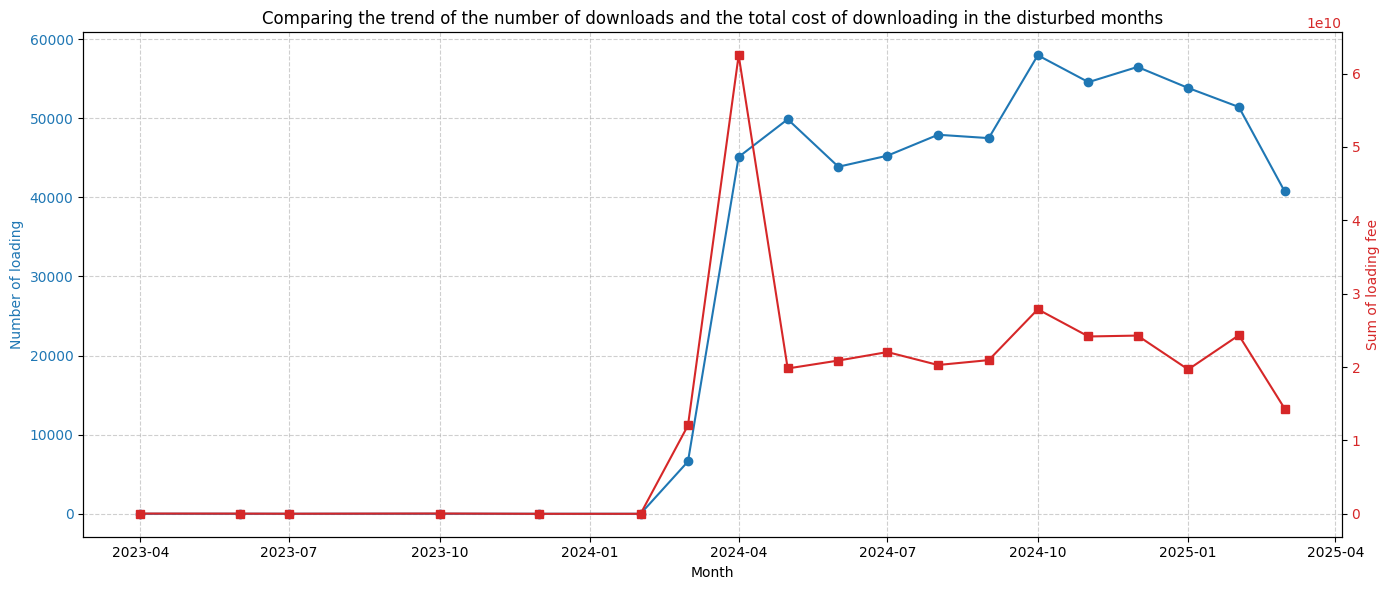

In [ ]:
import matplotlib.pyplot as plt

# گروه بندی بر اساس ماه
loading_by_month = df.groupby(df['Date of issue'].dt.to_period('M')).agg(
    LoadingCount=('Loader code', 'count'),
    TotalLoadingFee=('Loading fee', 'sum')
).reset_index()

# تبدیل تاریخ به timestamp برای نمایش درست در نمودار
loading_by_month['Date of issue'] = loading_by_month['Date of issue'].dt.to_timestamp()

# رسم نمودار
fig, ax1 = plt.subplots(figsize=(14,6))

# محور اول: تعداد بارگیری
color = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of loading', color=color)
ax1.plot(loading_by_month['Date of issue'], loading_by_month['LoadingCount'], marker='o', color=color, label='Number of loading')
ax1.tick_params(axis='y', labelcolor=color)

# محور دوم: هزینه بارگیری
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Sum of loading fee', color=color)
ax2.plot(loading_by_month['Date of issue'], loading_by_month['TotalLoadingFee'], marker='s', color=color, label='Sum of loading fee')
ax2.tick_params(axis='y', labelcolor=color)

# عنوان و شبکه
plt.title("Comparing the trend of the number of downloads and the total cost of downloading in the disturbed months")
ax1.grid(True, linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

In [ ]:
import jdatetime

def get_persian_season(date):
    persian_date = jdatetime.date.fromgregorian(date=date)
    if persian_date.month in [1, 2, 3]:
        return 'بهار'
    elif persian_date.month in [4, 5, 6]:
        return 'تابستان'
    elif persian_date.month in [7, 8, 9]:
        return 'پاییز'
    else:
        return 'زمستان'

df['Season'] = df['Date of issue'].apply(get_persian_season)

In [ ]:
seasonal_analysis = df.groupby(['product code','product name', 'Season']).agg(
    LoadingCount=('product code', 'count'),      # تعداد بارگیری
    TotalWeight=('weight', 'sum'),               # مجموع وزن
    TotalFee=('Loading fee', 'sum')              # مجموع هزینه بارگیری
).reset_index()

seasonal_analysis

,product code,product name,Season,LoadingCount,TotalWeight,TotalFee
0,1110000,انواع حبوبات,بهار,4,27000,0
1,1110000,انواع حبوبات,تابستان,6,50000,0
2,1110000,انواع حبوبات,زمستان,24,151020,3700000
3,1110000,انواع حبوبات,پاییز,10,50500,0
4,1110001,حبوبات انواع,بهار,2,9500,600000
...,...,...,...,...,...,...
4571,9600600,سواري تصادفي,بهار,51,126700,47888053
4572,9600600,سواري تصادفي,تابستان,34,84200,2300003
4573,9600600,سواري تصادفي,زمستان,68,173350,5000002
4574,9600600,سواري تصادفي,پاییز,59,174900,4000007


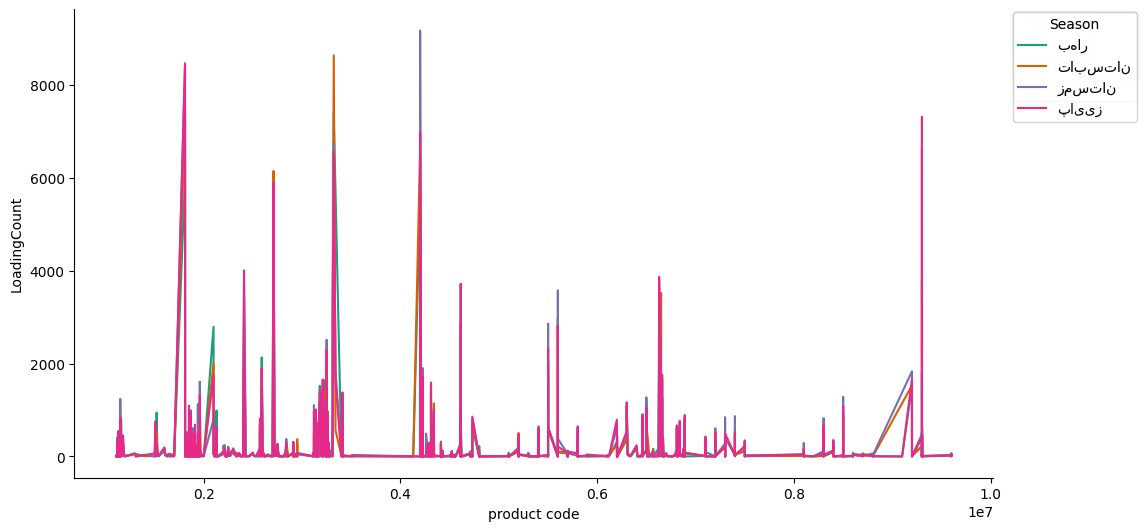

In [ ]:
# @title product code vs LoadingCount

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['product code']
  ys = series['LoadingCount']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = seasonal_analysis.sort_values('product code', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Season')):
  _plot_series(series, series_name, i)
  fig.legend(title='Season', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('product code')
_ = plt.ylabel('LoadingCount')

## نمودار فوق بر اساس فصل در پاور بی آی به صورت واضح تر و کاملا صریح بررسی شد که لینکشو در گزاررشات مربوط به این قسمت قرار دادم

In [ ]:
import pandas as pd

# فرض می‌کنیم ستون Season رو قبلاً ساخته‌ای

# ساخت ستون LoadingCount با گروه‌بندی
df['LoadingCount'] = df.groupby(['product code', 'Season'])['product code'].transform('count')

# انتخاب ستون‌های مورد نیاز برای خروجی
final_df = df[['product code', 'product name', 'Season', 'LoadingCount', 'Loading fee', 'weight', 'Date of issue']]

# ذخیره به فایل Excel
final_df.to_excel('seasonal_loading_analysis.xlsx', index=False)

## **خوشه بندی بر اساس رفتار هزینه ای**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# محاسبه ویژگی‌های هزینه‌ای
df['driver_profit'] = df['Total fare'] - (
    df['Company commission'] + df['Insurance amount'] +
    df['Scale fee'] + df['Evacuation fee'] +
    df['Loading fee'] + df['rent']
)

df['commission_ratio'] = df['Company commission'] / df['Total fare']
df['insurance_ratio'] = df['Insurance amount'] / df['Total fare']
df['handling_ratio'] = (df['Evacuation fee'] + df['Loading fee']) / df['Total fare']
df['cost_per_km'] = (df['Company commission'] + df['Insurance amount'] +
                     df['Evacuation fee'] + df['Loading fee']) / df['distance']
df['cost_per_kg'] = (df['Company commission'] + df['Insurance amount']) / df['weight']

#  گروه‌بندی راننده
df_driver = df.groupby('Driver smart card').agg({
    'driver_profit': 'sum',
    'commission_ratio': 'mean',
    'insurance_ratio': 'mean',
    'handling_ratio': 'mean',
    'cost_per_km': 'mean',
    'cost_per_kg': 'mean',
    'Bill of lading number': 'count'
}).reset_index()

df_driver.rename(columns={'Bill of lading number': 'trip_count'}, inplace=True)

features = ['commission_ratio', 'insurance_ratio', 'handling_ratio',
            'driver_profit', 'cost_per_km', 'cost_per_kg', 'trip_count']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_driver[features])

kmeans = KMeans(n_clusters=4, random_state=42)
df_driver['Cluster'] = kmeans.fit_predict(X_scaled)

print(df_driver[['Driver smart card', 'Cluster']])
df_driver.to_csv("clustered_drivers.csv", index=False)

        Driver smart card  Cluster
0                 1100240        2
1                 1100314        2
2                 1100321        2
3                 1100324        0
4                 1100378        2
...                   ...      ...
102257            4680968        2
102258            4681208        0
102259            4681487        0
102260            4681565        2
102261            4683359        2

[102262 rows x 2 columns]


In [ ]:
# نمایش 30 راننده تصادفی از هر خوشه
for cluster in df_driver['Cluster'].unique():
    print(f"\n=== نمونه راننده‌های خوشه {cluster} ===")
    sample = df_driver[df_driver['Cluster'] == cluster].sample(n=10, random_state=42)
    print(sample[['Driver smart card', 'driver_profit', 'trip_count', 'commission_ratio']])


=== نمونه راننده‌های خوشه 2 ===
       Driver smart card  driver_profit  trip_count  commission_ratio
89510            3779848        5626400           2          0.027205
71266            3212213        5223750           1          0.043668
57947            2892883       15188900           1          0.027513
76821            3323818        8278813           2          0.039318
33565            2223081       10865440           1          0.012313
44272            2551407        2857118           2          0.044045
42779            2514003        1833739           1          0.033691
11995            1292243        9105500           1          0.022927
11777            1287709       13825500           1          0.043523
36011            2292829      202982969          22          0.042880

=== نمونه راننده‌های خوشه 0 ===
        Driver smart card  driver_profit  trip_count  commission_ratio
1901              1132652       15435800           1          0.077213
60678             2946

تحلیل هر خوشه با  استفاده از ویژگی های عددی

In [ ]:
# تحلیل ویژگی‌های هر خوشه
df_analysis = df_driver.groupby('Cluster')[features].mean()
print(df_analysis)

         commission_ratio  insurance_ratio  handling_ratio  driver_profit  \
Cluster                                                                     
0                0.076935         0.014889        0.005665   2.261780e+07   
1                0.047908         0.017419        0.006402   4.597780e+08   
2                0.031762         0.011326        0.007501   2.745092e+07   
3                0.069564         0.019992        0.013170   1.431052e+07   

          cost_per_km    cost_per_kg  trip_count  
Cluster                                           
0        26413.741864    1457.732708    3.414531  
1        28431.356270     914.857007  120.329708  
2        10050.081425     646.392960    4.256431  
3        34845.313748  607719.054134    1.500000  


In [ ]:
df_company = df.groupby('Company Code').agg({
    'driver_profit': 'sum',
    'commission_ratio': 'mean',
    'insurance_ratio': 'mean',
    'handling_ratio': 'mean',
    'cost_per_km': 'mean',
    'cost_per_kg': 'mean',
    'Bill of lading number': 'count'
}).reset_index()

df_company.rename(columns={'Bill of lading number': 'trip_count'}, inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_company[features])

kmeans = KMeans(n_clusters=4, random_state=42)
df_company['Cluster'] = kmeans.fit_predict(X_scaled)

print(df_company[['Company Code', 'Cluster']])
df_company.to_csv("clustered_companies.csv", index=False)


     Company Code  Cluster
0       111100004        1
1       111100085        0
2       111100126        3
3       111100182        1
4       111100195        0
..            ...      ...
362     979700726        0
363     979700727        0
364     979700735        1
365     979700747        0
366     979700748        0

[367 rows x 2 columns]


In [ ]:
# فرض: df اصلی همون دیتاست کامل شرکت‌هاست و df_company خروجی خوشه‌بندی (کد و خوشه)
df_company_full = df.merge(df_company[['Company Code', 'Cluster']], on='Company Code', how='inner')

# نمایش 10 نمونه تصادفی از هر خوشه شرکت
for cluster in df_company_full['Cluster'].unique():
    cluster_data = df_company_full[df_company_full['Cluster'] == cluster]
    print(f"\n=== نمونه شرکت‌های خوشه {cluster} (تعداد: {len(cluster_data)}) ===")
    sample_size = min(10, len(cluster_data))
    sample = cluster_data.sample(n=sample_size, random_state=42)
    print(sample[['Company Code', 'Total fare', 'Company commission', 'Insurance amount']])



=== نمونه شرکت‌های خوشه 0 (تعداد: 218137) ===
        Company Code  Total fare  Company commission  Insurance amount
179391     141400044    56600000             2290620           3768000
126780     141400018    25500000              961895            395000
309697     141400048    32000000             2367155            375000
469305     141400022   130000000            10450000           4115000
271212     141400015    23536460              422080              5000
213967     141400013    63226500             1120000            715000
29602      141400020    35209000              915000            815000
537452     141400048   138000000            11456067           1000000
342027     141400049    74707750             1340000              2500
469024     141400019   111417625             2035000              1250

=== نمونه شرکت‌های خوشه 1 (تعداد: 60431) ===
        Company Code  Total fare  Company commission  Insurance amount
246828     646400199   113622500             9050000   

In [ ]:
features_company = ['Company commission', 'Insurance amount', 'Total fare', 'distance', 'weight']
cluster_analysis = df_company_full.groupby('Cluster')[features_company].mean()
print("\n--- تحلیل رفتار هزینه‌ای خوشه‌ها ---\n")
print(cluster_analysis)


--- تحلیل رفتار هزینه‌ای خوشه‌ها ---

         Company commission  Insurance amount    Total fare    distance  \
Cluster                                                                   
0              2.549061e+06      7.055540e+05  7.953780e+07  441.593104   
1              8.570394e+06      1.184829e+06  1.019243e+08  485.208734   
2              4.895936e+06      1.280770e+06  8.665103e+07  437.487870   
3              1.165852e+06      8.734796e+05  2.610563e+07  125.301741   

               weight  
Cluster                
0        11300.397764  
1        14267.354818  
2        11570.881883  
3         6106.990329  


Radar Chart

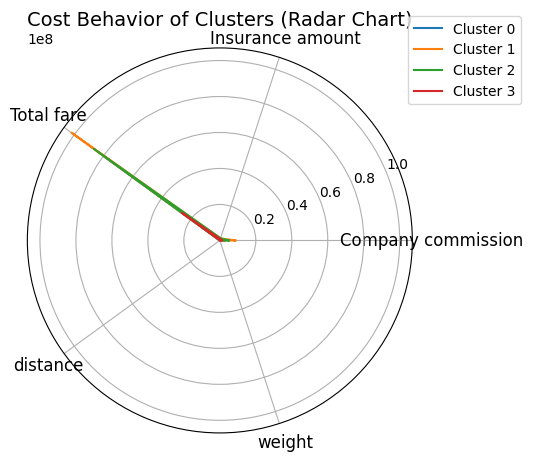

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cluster_analysis = df_company_full.groupby('Cluster')[['Company commission', 'Insurance amount', 'Total fare', 'distance', 'weight']].mean()

categories = list(cluster_analysis.columns)
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(5,5))

for cluster in cluster_analysis.index:
    values = cluster_analysis.loc[cluster].tolist()
    values += values[:1]
    plt.polar(angles, values, label=f'Cluster {cluster}')

plt.xticks(angles[:-1], categories, fontsize=12)
plt.title("Cost Behavior of Clusters (Radar Chart)", fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

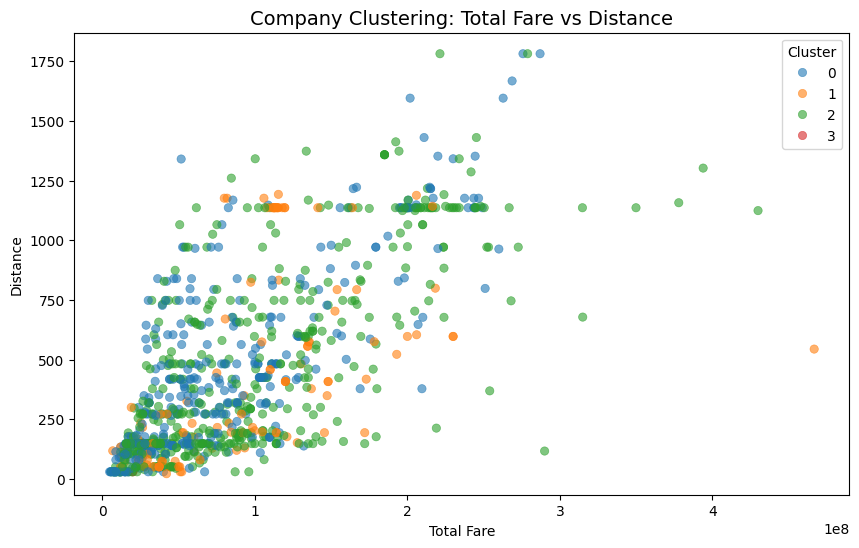

In [ ]:
import seaborn as sns
sample_df = df_company_full.sample(n=min(1000, len(df_company_full)), random_state=42)

plt.figure(figsize=(10,6))
sns.scatterplot(data=sample_df,
                x='Total fare',
                y='distance',
                hue='Cluster',
                palette='tab10',
                alpha=0.6,    # شفافیت برای بهتر دیدن نقاط روی هم
                edgecolor=None)

plt.title("Company Clustering: Total Fare vs Distance", fontsize=14)
plt.xlabel("Total Fare")
plt.ylabel("Distance")
plt.legend(title="Cluster")
plt.show()

## **خوشه بندی مسیر ها بر اساس تاخیر و مسافت و کرایه**

In [ ]:
df['date of interception'].head()

,date of interception
0,1403/01/05
1,1403/01/05
2,1403/01/05
3,1403/01/05
4,1403/01/05


In [ ]:
df['Bill of lading registration time'].head()

,Bill of lading registration time
0,14:04
1,13:21
2,13:12
3,13:16
4,13:28


In [ ]:
import pandas as pd
import jdatetime

print(" قبل از تبدیل:")
print(df['date of interception'])
print(df['date of interception'].dtype)  # نوع ستون قبل از تبدیل

# تابع تبدیل شمسی به میلادی
def shamsi_to_gregorian(date_str):
    try:
        y, m, d = map(int, date_str.split('/'))
        return jdatetime.date(y, m, d).togregorian()
    except:
        return None  # اگه تاریخ خراب بود یا NaN بود

# تبدیل به میلادی
df['date of interception'] = df['date of interception'].apply(shamsi_to_gregorian)

 قبل از تبدیل:
0         1403/01/05
1         1403/01/05
2         1403/01/05
3         1403/01/05
4         1403/01/05
             ...    
601212    1403/12/27
601213    1403/12/27
601214    1403/12/28
601215    1403/12/28
601216    1403/12/27
Name: date of interception, Length: 601217, dtype: object
object


In [ ]:
# تبدیل نوع ستون به datetime پانداس
df['date of interception'] = pd.to_datetime(df['date of interception'])
df['date of interception'] = pd.to_datetime(df['date of interception'])

print("\n بعد از تبدیل:")
print(df['date of interception'])
print(df['date of interception'].dtype)  # نوع ستون بعد از تبدیل


 بعد از تبدیل:
0        2024-03-24
1        2024-03-24
2        2024-03-24
3        2024-03-24
4        2024-03-24
            ...    
601212   2025-03-17
601213   2025-03-17
601214   2025-03-18
601215   2025-03-18
601216   2025-03-17
Name: date of interception, Length: 601217, dtype: datetime64[ns]
datetime64[ns]


## !نمیدونم مشکلش با تاریخ رهگیری چی هست که  بعد از تبدیل مقادیرش  خالی می شوند

    Delay_days  distance  Total fare  Cluster
0            1       148    75064000        0
1            1       148    75064000        0
2            1       148    75299000        0
3            1       148    75299000        0
4            1       370    22738500        0
5            1       150    21985020        0
6            1       150    21985020        0
7            1       150    16510020        0
8            1       150    21985020        0
9            1       150    21985020        0
10           1       150    21985020        0
11          19      1352   204923600        1
12           1      1352   204923600        1
13           1      1352   204923600        1
14           1      1352   204923600        1
15           1      1352   204923600        1
16           1      1352   204923600        1
17           1      1352   204923600        1
18           1      1352   204923600        1
19           1      1352   204923600        1
20           1      1352   2049236

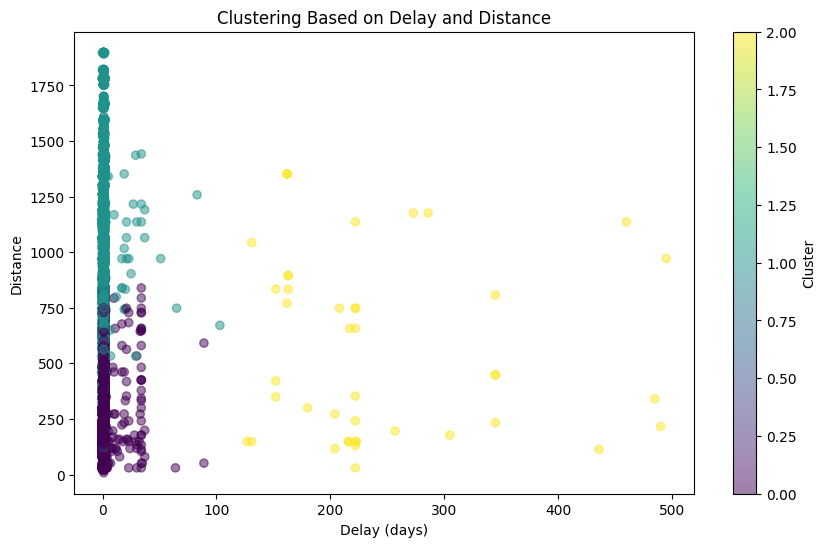

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# فرض: df شامل ستون‌های 'Delivery date', 'Date of issue', 'distance', 'Total fare'

# تبدیل ستون‌های تاریخ به datetime
df['Delivery_date'] = pd.to_datetime(df['Delivery date'])
df['Issue_date'] = pd.to_datetime(df['Date of issue'])

# محاسبه تاخیر به روز (مدت زمان بین صدور و تحویل)
df['Delay_days'] = (df['Delivery_date'] - df['Issue_date']).dt.days

# انتخاب ویژگی‌ها: تاخیر، مسافت و کرایه
X = df[['Delay_days', 'distance', 'Total fare']]

# نرمال‌سازی ویژگی‌ها
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# اجرای KMeans با 3 خوشه (تعداد خوشه‌ها را می‌توان تغییر داد)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# نمایش چند نمونه خروجی
print(df[['Delay_days', 'distance', 'Total fare', 'Cluster']].head(30))

# رسم نمودار دو بعدی برای نمایش خوشه‌ها (Delay_days در محور x و distance در محور y)
plt.figure(figsize=(10,6))
plt.scatter(df['Delay_days'], df['distance'], c=df['Cluster'], cmap='viridis', alpha=0.5)
plt.xlabel('Delay (days)')
plt.ylabel('Distance')
plt.title('Clustering Based on Delay and Distance')
plt.colorbar(label='Cluster')
plt.show()
